# Notebook 01 — Data Acquisition & EDA

**Project:** MarketMind AI — Review Intelligence for Marketing Generation  
**Author:** Will  
**Date:** March 2026  

**Purpose:**
1. Stream reviews from 10 broad Amazon product categories
2. Sample an equal share from each category (50K total for MVP)
3. Collapse star ratings into 3-class sentiment labels (positive / neutral / negative)
4. Save the combined multi-category dataset to Google Drive as parquet
5. Run initial EDA: label distribution, review lengths, per-category breakdown, data quality

**Output:** `data/raw/reviews_50k.parquet` on Google Drive

#### 1. Setup

In [1]:
!pip install -q datasets pyarrow

In [2]:
import os
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")

PROJECT_ROOT = "/content/drive/MyDrive/LAU FINAL PROJECT"

DATA_RAW = os.path.join(PROJECT_ROOT, "data", "raw")
DATA_PROCESSED = os.path.join(PROJECT_ROOT, "data", "processed")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")

for d in [DATA_RAW, DATA_PROCESSED, MODELS_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Exists: {os.path.exists(PROJECT_ROOT)}")
print(f"Contents: {os.listdir(PROJECT_ROOT)}")

Mounted at /content/drive
Project root: /content/drive/MyDrive/LAU FINAL PROJECT
Exists: True
Contents: ['proposal', 'data', 'models']


#### 2. Category Selection

The Amazon Reviews 2023 dataset has ~33 categories. We selected 10 that are broad, have descriptive reviews, and represent real product marketing use cases.

Each category gets an equal share so the sentiment classifier learns language patterns across all of them — not just one niche.

In [4]:
CATEGORIES = [
    "Beauty_and_Personal_Care",
    "Electronics",
    "Home_and_Kitchen",
    "Sports_and_Outdoors",
    "Toys_and_Games",
    "Pet_Supplies",
    "Health_and_Household",
    "Baby_Products",
    "Office_Products",
    "Tools_and_Home_Improvement",
]

TOTAL_SAMPLE = 50_000  # MVP size
PER_CATEGORY = TOTAL_SAMPLE // len(CATEGORIES)  # 5,000 each
STREAM_LIMIT = 50_000  # stream this many per category, then sample from them
SEED = 42

print(f"Categories: {len(CATEGORIES)}")
print(f"Reviews per category: {PER_CATEGORY:,}")
print(f"Total dataset size: {TOTAL_SAMPLE:,}")
print(f"\nCategories:")
for cat in CATEGORIES:
    print(f"  - {cat}")

Categories: 10
Reviews per category: 5,000
Total dataset size: 50,000

Categories:
  - Beauty_and_Personal_Care
  - Electronics
  - Home_and_Kitchen
  - Sports_and_Outdoors
  - Toys_and_Games
  - Pet_Supplies
  - Health_and_Household
  - Baby_Products
  - Office_Products
  - Tools_and_Home_Improvement


#### 3. Download & Sample (Top-Reviewed Products)

For each category: stream reviews, find the products with the most reviews, and keep all reviews for those top products until we reach 5K per category.

This ensures dense review coverage per product — critical for building reliable sentiment profiles in the ranking stage.

In [ ]:
all_samples = []

for cat in CATEGORIES:
    print(f"Streaming {cat}...")
    data_file = (
        "hf://datasets/McAuley-Lab/Amazon-Reviews-2023/"
        f"raw/review_categories/{cat}.jsonl"
    )
    ds = load_dataset(
        "json",
        data_files=data_file,
        split="train",
        streaming=True,
    )

    # Stream up to STREAM_LIMIT reviews
    reviews = []
    for i, example in enumerate(ds):
        if i >= STREAM_LIMIT:
            break
        reviews.append(example)

    df_cat = pd.DataFrame(reviews)
    df_cat["category"] = cat

    # Find top-reviewed products by parent_asin
    product_col = "parent_asin" if "parent_asin" in df_cat.columns else "asin"
    product_counts = df_cat[product_col].value_counts()

    # Take top products until we have enough reviews
    selected_reviews = pd.DataFrame()
    for product_id in product_counts.index:
        product_reviews = df_cat[df_cat[product_col] == product_id]
        selected_reviews = pd.concat([selected_reviews, product_reviews])
        if len(selected_reviews) >= PER_CATEGORY:
            break

    # Trim to exactly PER_CATEGORY
    selected_reviews = selected_reviews.head(PER_CATEGORY)
    all_samples.append(selected_reviews)

    n_products = selected_reviews[product_col].nunique()
    print(f"  Streamed {len(reviews):,} → kept {len(selected_reviews):,} reviews from {n_products} top products")

    # Free memory
    del reviews, df_cat, selected_reviews

# Combine all categories
df = pd.concat(all_samples, ignore_index=True)
del all_samples

print(f"\nTotal dataset: {len(df):,} reviews across {df['category'].nunique()} categories")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

#### 4. Clean & Create Labels

Collapse star ratings into 3 sentiment classes:
- **Positive** — 4-5 stars
- **Neutral** — 3 stars
- **Negative** — 1-2 stars

Star ratings are a noisy proxy for sentiment. A 3-star review saying "love the product, terrible shipping" is mixed but gets labeled neutral. This is acknowledged and analyzed in the evaluation.

In [25]:
# Check available columns
print("Columns:", df.columns.tolist())
print(f"\nShape before cleaning: {df.shape}")

# Drop rows with empty or null review text
df = df[df["text"].notna() & (df["text"].str.strip() != "")].reset_index(drop=True)
print(f"Shape after dropping empty text: {df.shape}")

# Collapse star ratings to 3 classes
def collapse_rating(rating):
    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    else:
        return "positive"

df["sentiment"] = df["rating"].apply(collapse_rating)

# Add text length (word count)
df["text_length"] = df["text"].str.split().str.len()

# Keep useful columns only
keep_cols = [
    "asin", "parent_asin", "rating", "text", "title",
    "sentiment", "text_length", "category", "verified_purchase",
    "helpful_vote", "timestamp",
]
keep_cols = [c for c in keep_cols if c in df.columns]
df = df[keep_cols]

print(f"\nFinal shape: {df.shape}")
print(f"Columns kept: {df.columns.tolist()}")
df.head(3)

Columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase', 'category']

Shape before cleaning: (50000, 11)
Shape after dropping empty text: (49994, 11)

Final shape: (49994, 11)
Columns kept: ['asin', 'parent_asin', 'rating', 'text', 'title', 'sentiment', 'text_length', 'category', 'verified_purchase', 'helpful_vote', 'timestamp']


,asin,parent_asin,rating,text,title,sentiment,text_length,category,verified_purchase,helpful_vote,timestamp
0,B086QHDYLS,B0BRJ5Q4X8,5.0,Mamonde has some very nice products. This flor...,Fantastic moisturizer that smells amazing,positive,115,Beauty_and_Personal_Care,False,0,1606667965761
1,B07NSLZGDQ,B08J96BMCY,5.0,For a handmade soap. I am so impressed. It rea...,Beautiful soap!,positive,51,Beauty_and_Personal_Care,False,0,1562959767970
2,B07VQR2RQ6,B07VQR2RQ6,5.0,"Easy way to handle a pony, making it look clas...",Great.,positive,18,Beauty_and_Personal_Care,True,0,1579904491568


#### 5. Save to Google Drive

In [26]:
output_path = os.path.join(DATA_RAW, "reviews_50k.parquet")

df.to_parquet(output_path, index=False)

file_size_mb = os.path.getsize(output_path) / 1e6
print(f"Saved {len(df):,} reviews to: {output_path}")
print(f"File size: {file_size_mb:.1f} MB")

Saved 49,994 reviews to: /content/drive/MyDrive/LAU FINAL PROJECT/data/raw/reviews_50k.parquet
File size: 13.0 MB


#### 6. EDA — Label Distribution

Amazon reviews are typically positive-skewed. Heavy imbalance means we may need class weighting during training.

Overall Label Distribution:
----------------------------------------
    positive: 41,477 (83.0%)
     neutral:  3,686 (7.4%)
    negative:  4,831 (9.7%)
       Total: 49,994


/tmp/ipykernel_3683/3352410560.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=order, y=[class_counts.get(l, 0) for l in order], palette=colors, ax=axes[0])


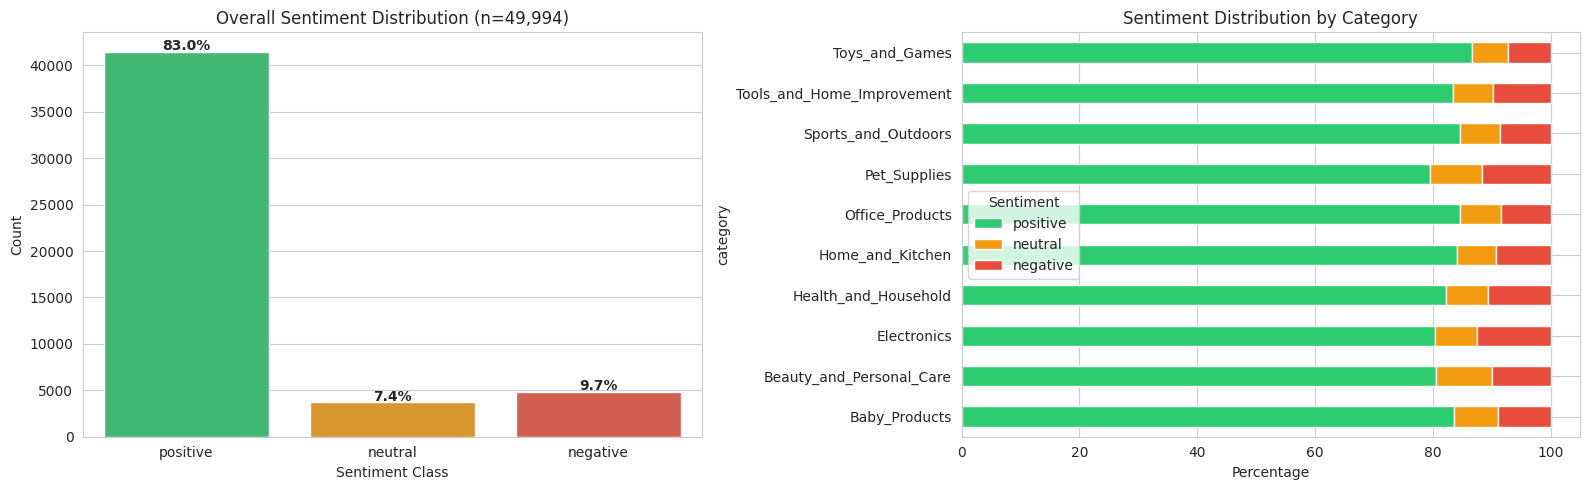


Imbalance ratio (majority:minority): 11.3:1
Class weighting will likely be needed during training.


In [27]:
# Overall class counts and percentages
class_counts = df["sentiment"].value_counts()
class_pcts = df["sentiment"].value_counts(normalize=True) * 100

print("Overall Label Distribution:")
print("-" * 40)
for label in ["positive", "neutral", "negative"]:
    count = class_counts.get(label, 0)
    pct = class_pcts.get(label, 0)
    print(f"  {label:>10}: {count:>6,} ({pct:.1f}%)")
print(f"  {'Total':>10}: {len(df):>6,}")

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Overall sentiment
order = ["positive", "neutral", "negative"]
colors = ["#2ecc71", "#f39c12", "#e74c3c"]
sns.barplot(x=order, y=[class_counts.get(l, 0) for l in order], palette=colors, ax=axes[0])
axes[0].set_title(f"Overall Sentiment Distribution (n={len(df):,})")
axes[0].set_xlabel("Sentiment Class")
axes[0].set_ylabel("Count")
for i, label in enumerate(order):
    count = class_counts.get(label, 0)
    pct = class_pcts.get(label, 0)
    axes[0].text(i, count + 200, f"{pct:.1f}%", ha="center", fontweight="bold")

# Per-category breakdown
cat_sentiment = df.groupby(["category", "sentiment"]).size().unstack(fill_value=0)
cat_sentiment_pct = cat_sentiment.div(cat_sentiment.sum(axis=1), axis=0) * 100
cat_sentiment_pct[order].plot(kind="barh", stacked=True, color=colors, ax=axes[1])
axes[1].set_title("Sentiment Distribution by Category")
axes[1].set_xlabel("Percentage")
axes[1].legend(title="Sentiment")

plt.tight_layout()
plt.show()

# Imbalance ratio
majority = class_counts.max()
minority = class_counts.min()
print(f"\nImbalance ratio (majority:minority): {majority/minority:.1f}:1")
print("Class weighting will likely be needed during training.")

#### 7. EDA — Review Length

Review length informs the `max_length` parameter for DistilBERT tokenization later.

Review Length (word count) by Sentiment Class:
             count  mean  median  min     max   95th
sentiment                                           
negative    4831.0  59.4    34.0  1.0  2065.0  193.5
neutral     3686.0  75.4    43.5  1.0  1319.0  252.8
positive   41477.0  60.3    33.0  1.0  1913.0  209.0


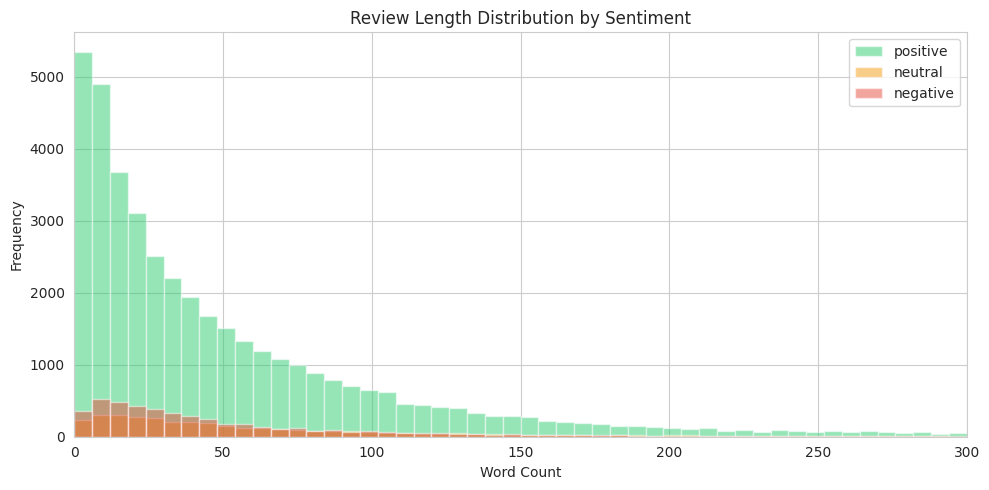


95th percentile review length (overall): 211 words
Recommended DistilBERT max_length: 316 tokens
(Tokens ~ 1.3x words on average for English text)


In [28]:
# Length stats per class
length_stats = df.groupby("sentiment")["text_length"].describe()
length_stats["95th"] = df.groupby("sentiment")["text_length"].quantile(0.95)
print("Review Length (word count) by Sentiment Class:")
print(length_stats[["count", "mean", "50%", "min", "max", "95th"]].rename(
    columns={"50%": "median"}
).round(1))

# Histogram
fig, ax = plt.subplots(figsize=(10, 5))
for label, color in zip(["positive", "neutral", "negative"], ["#2ecc71", "#f39c12", "#e74c3c"]):
    subset = df[df["sentiment"] == label]["text_length"]
    ax.hist(subset, bins=50, alpha=0.5, label=label, color=color, range=(0, 300))
ax.set_title("Review Length Distribution by Sentiment")
ax.set_xlabel("Word Count")
ax.set_ylabel("Frequency")
ax.legend()
ax.set_xlim(0, 300)
plt.tight_layout()
plt.show()

# DistilBERT max_length recommendation
p95_overall = df["text_length"].quantile(0.95)
print(f"\n95th percentile review length (overall): {p95_overall:.0f} words")
print(f"Recommended DistilBERT max_length: {min(int(p95_overall * 1.5), 512)} tokens")
print("(Tokens ~ 1.3x words on average for English text)")

#### 8. EDA — Example Reviews

Sanity check — do the collapsed labels make sense when you read the actual text?

In [29]:
for label in ["positive", "neutral", "negative"]:
    print(f"\n{'=' * 60}")
    print(f"  {label.upper()} — 3 random examples")
    print(f"{'=' * 60}")
    samples = df[df["sentiment"] == label].sample(3, random_state=SEED)
    for _, row in samples.iterrows():
        text = row["text"][:300] + ("..." if len(row["text"]) > 300 else "")
        cat = row.get("category", "N/A")
        print(f"\n  [{cat}] {row['rating']:.0f} stars | {row['text_length']} words")
        print(f"  {text}")
        print()


  POSITIVE — 3 random examples

  [Sports_and_Outdoors] 5 stars | 14 words
  Exactly what I wanted I love it very Diablo cheap price super fast delivery


  [Toys_and_Games] 5 stars | 14 words
  Fun family game if you are avid watchers of SNL. It was very fun.


  [Sports_and_Outdoors] 5 stars | 11 words
  Awesome ball. Works great for my 10 year olds soccer league.


  NEUTRAL — 3 random examples

  [Tools_and_Home_Improvement] 3 stars | 215 words
  I purchased these Scissors through a promotion, although my wife already owned a pair of similar scissors from Cutco. We've had them for about ten years now. But I was curious as to how these scissors compared to our old brand. They both come apart, however the Cutco brand is a bit heavier than this...


  [Office_Products] 3 stars | 36 words
  These are smaller than 6x10 on the inside. The color is pretty, but shipping labels don't stick really well on them. They will stick but you have to make sure they are all the way on.


  [Baby_Pro

#### 9. EDA — Data Quality & Product Distribution

Products with very few reviews won't have reliable sentiment profiles for the ranking stage. This tells us the realistic floor for product-level analysis.

In [30]:
# Use parent_asin if available, otherwise asin
product_col = "parent_asin" if "parent_asin" in df.columns else "asin"

reviews_per_product = df[product_col].value_counts()

print("Reviews per Product:")
print("-" * 40)
print(f"  Total unique products: {len(reviews_per_product):,}")
print(f"  Mean reviews/product:  {reviews_per_product.mean():.1f}")
print(f"  Median reviews/product: {reviews_per_product.median():.1f}")
print(f"  Max reviews/product:   {reviews_per_product.max():,}")
print()

# Distribution buckets
buckets = [
    ("1 review", reviews_per_product == 1),
    ("2-5 reviews", (reviews_per_product >= 2) & (reviews_per_product <= 5)),
    ("6-10 reviews", (reviews_per_product >= 6) & (reviews_per_product <= 10)),
    ("11-50 reviews", (reviews_per_product >= 11) & (reviews_per_product <= 50)),
    ("50+ reviews", reviews_per_product > 50),
]

print("Product Distribution by Review Count:")
print("-" * 40)
for label, mask in buckets:
    count = mask.sum()
    pct = count / len(reviews_per_product) * 100
    print(f"  {label:>15}: {count:>6,} products ({pct:.1f}%)")

# Products with enough reviews for reliable sentiment profiles
min_reviews = 10
reliable_products = (reviews_per_product >= min_reviews).sum()
reliable_reviews = df[df[product_col].isin(
    reviews_per_product[reviews_per_product >= min_reviews].index
)].shape[0]
print(f"\nProducts with {min_reviews}+ reviews (usable for ranking): {reliable_products:,}")
print(f"These cover {reliable_reviews:,} reviews ({reliable_reviews/len(df)*100:.1f}% of data)")

Reviews per Product:
----------------------------------------
  Total unique products: 44,745
  Mean reviews/product:  1.1
  Median reviews/product: 1.0
  Max reviews/product:   179

Product Distribution by Review Count:
----------------------------------------
         1 review: 41,439 products (92.6%)
      2-5 reviews:  3,203 products (7.2%)
     6-10 reviews:     87 products (0.2%)
    11-50 reviews:     13 products (0.0%)
      50+ reviews:      3 products (0.0%)

Products with 10+ reviews (usable for ranking): 20
These cover 615 reviews (1.2% of data)


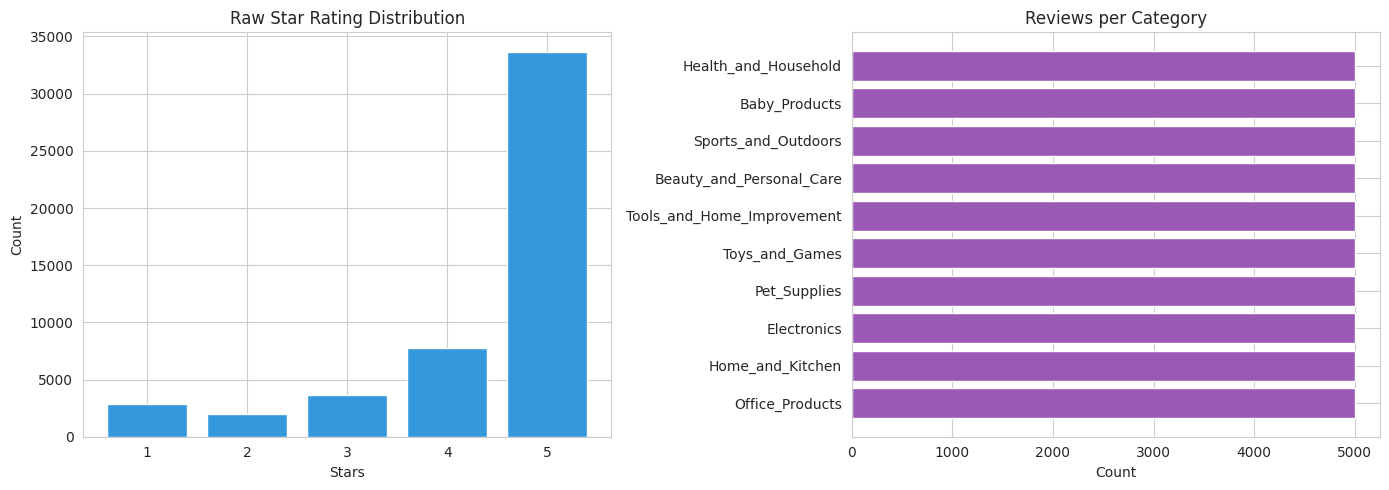

In [31]:
# Raw star distribution and reviews per category
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw star distribution
star_counts = df["rating"].value_counts().sort_index()
axes[0].bar(star_counts.index, star_counts.values, color="#3498db")
axes[0].set_title("Raw Star Rating Distribution")
axes[0].set_xlabel("Stars")
axes[0].set_ylabel("Count")
axes[0].set_xticks([1, 2, 3, 4, 5])

# Reviews per category
cat_counts = df["category"].value_counts().sort_values()
axes[1].barh(cat_counts.index, cat_counts.values, color="#9b59b6")
axes[1].set_title("Reviews per Category")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.show()

#### 10. Summary & Next Steps

**What this notebook produced:**
- 50K reviews across 10 categories, saved to `data/raw/reviews_50k.parquet`
- 3-class sentiment labels (positive / neutral / negative)
- EDA confirming data quality, class balance, and review characteristics

**Key findings:** _(fill in after running)_

**Next:** Train TF-IDF + Logistic Regression baseline on this data.